In [1]:

import sys
sys.path.append('../')
from utils_models import *

In [6]:
def get_dressed_state_overlaps(hamiltonian, product_index):
    """
    For a given product state index, finds the dressed states with decreasing overlap and the corresponding overlaps.
    
    Parameters:
    - H_with_interaction_no_drive: Hamiltonian in the product basis of a coupled system.
    - product_index: Index of the product state for which overlaps are calculated.
    
    Returns:
    - dressed_indices: Indices of the dressed states ordered by decreasing overlap with the product state.
    - overlaps: Overlaps of the dressed states with the product state.
    """
    # Compute eigenstates of the Hamiltonian
    evals, evecs = hamiltonian.eigenstates()
    overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)

    # Extract overlaps for the specified product state with all dressed states
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    
    # Sort the dressed states by decreasing overlap with the product state
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]  # Indices of dressed states sorted by overlap
    sorted_overlaps = overlaps_with_product_state[sorted_indices]  # Sorted overlaps
    
    return list(sorted_indices), list(sorted_overlaps)

def print_top_two_dressed_levels(hamiltonian, ql,ol,max_ql,max_ol):
    top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = hamiltonian,
                           product_index = ql * max_ol + ol)
    print(top_dressed_states[:2])
    print(overlaps[:2])

# Initialize a integer fluxonium - readout resonator system, and find the dressed indices of the hybridized states

In [3]:
qbt = scqubits.Fluxonium(EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    flux = 0,
    truncated_dim = 10,
    cutoff = 110)

qbt.eigenvals()[3] - qbt.eigenvals()[0]

2.8947132303123952

In [8]:
max_ql = 20
max_ol = 5
system = FluxoniumOscillatorSystem(
    computaional_states = '0,1',
    
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    
    Er = 2.8947132303123952 - 0.1,
    g_strength = 0.1,
    qubit_level = max_ql,
    osc_level = max_ol,

    kappa = 3e-2,
    products_to_keep=[[ql, ol] for ql in range(6) for ol in range(2) ],
    )

In [10]:
print_top_two_dressed_levels(hamiltonian = system.hilbertspace.hamiltonian(),
                             ql = 0,
                             ol = 1,
                             max_ql=max_ql,
                             max_ol=max_ol)

print_top_two_dressed_levels(hamiltonian = system.hilbertspace.hamiltonian(),
                             ql = 2,
                             ol = 0,
                             max_ql=max_ql,
                             max_ol=max_ol)

print_top_two_dressed_levels(hamiltonian = system.hilbertspace.hamiltonian(),
                             ql = 3,
                             ol = 0,
                             max_ql=max_ql,
                             max_ol=max_ol)

print_top_two_dressed_levels(hamiltonian = system.hilbertspace.hamiltonian(),
                             ql = 2,
                             ol = 1,
                             max_ql=max_ql,
                             max_ol=max_ol)


[3, 4]
[0.9297429764538165, 0.36712810927682515]
[2, 16]
[0.9999500818995929, 0.006523373651943483]
[4, 3]
[0.9299790854312743, 0.36718686589416044]
[7, 8]
[0.939111096046252, 0.3430864210501833]


In [10]:
# Find what dressed states make up the h0 (30) product state
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = system.hilbertspace.hamiltonian(),
                           product_index = 3 * system.osc.truncated_dim + 0)
top_dressed_states[:2], overlaps[:2]

([3, 8], [0.9999145998772693, 0.010492165861120758])

In [45]:
# Find what dressed states make up the (40) product state
top_dressed_states, overlaps = get_dressed_state_overlaps(hamiltonian = system.hilbertspace.hamiltonian(),
                           product_index = 4 * system.osc.truncated_dim + 0)
top_dressed_states[:2], overlaps[:2]

([5, 7], [0.998493288387191, 0.05322126791891457])

# Simulating the LRU protocol: drive h0 to lower hybridized state 3

In [39]:
# Step-1 compute the pulse time for a square pulse of amplitude 0.03
amp = 0.03
element = np.abs(system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator))[2,3]) 
square_t_stop = 0.5 / element /amp
# Step-2 compute the pulse time if we add sin^2 ring up and ring down
t_rise = 30
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (square_t_stop-area_under_rise_and_fall) + 53
# Step-3 include additional 500 ns decay time for the resonator
tot_time = int(t_stop + 500)
tlist = np.linspace(0, tot_time, tot_time)


In [40]:
kappa = 3e-2

results = system.run_mesolve_on_driving_osc(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(4)],
    tlist = tlist,
    osc_decay = True,
    e_ops=[# we want to get the expectation value of the system being in every one of its eigenstates
        system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension,i))) for i in [0,1,2,3,4,5,6,7]
    ],
    amp = amp,
    t_stop = t_stop,
    t_rise = t_rise,
    driven_operator=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator))
)


 Total run time:  17.66s*] Elapsed 17.66s / Remaining 00:00:00:00[*********76%*****      ] Elapsed 13.92s / Remaining 00:00:00:04
 [*********83%*******    ] Elapsed 17.75s / Remaining 00:00:00:03

Processing states with pad_back_custom: 100%|██████████| 738/738 [00:00<00:00, 5588.91it/s]


 Total run time:  19.92s*] Elapsed 19.92s / Remaining 00:00:00:00
 Total run time:  19.99s*] Elapsed 19.99s / Remaining 00:00:00:00
 [*********99%***********] Elapsed 20.02s / Remaining 00:00:00:00

Processing states with pad_back_custom: 100%|██████████| 738/738 [00:00<00:00, 5614.25it/s]


 Total run time:  20.17s*] Elapsed 20.17s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 738/738 [00:00<00:00, 5916.24it/s]


## For system starting in dressed state 2 (which is f0, the leakage state we are addressing) about 99.99% of the population has gone to state 0 (which is g0) at 700 ns

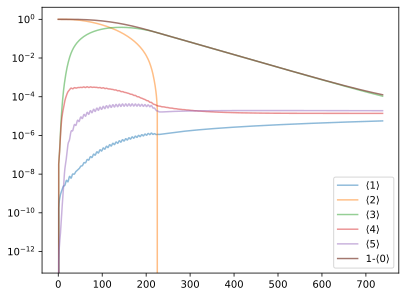

In [44]:
for i in [1,2,3, 4,5]:
    plt.plot(tlist,results[2].expect[i],label=fr'$\langle{i}\rangle$',alpha = 0.5)
plt.plot(tlist,1-results[2].expect[0],label=fr'1-$\langle{0}\rangle$',alpha = 0.8)
plt.legend()
plt.yscale('log')


## For system starting in dressed state 1 (which is e0, a computational state) the worried qubit 1-4 transition only happens at a level of 1e-4

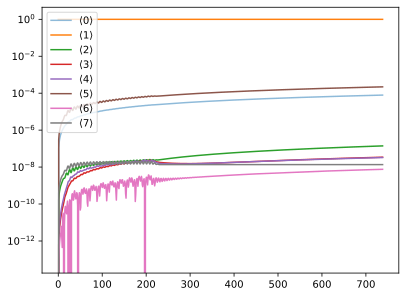

In [46]:

plt.plot(tlist,results[1].expect[0],label=fr'$\langle{0}\rangle$',alpha = 0.5)

for i in [1,2,3,4,5,6,7]:
    plt.plot(tlist,results[1].expect[i],label=fr'$\langle{i}\rangle$')
plt.legend()
# plt.ylim(0,1e-3)

plt.yscale('log')
# plt.xlim(0,186)

## For system starting in dressed state 0 (which is g0, a computational state) there's also some leakage on the level of 1e-5

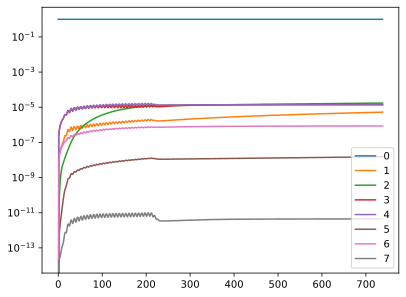

In [48]:
for i in [0,1,2,3,4,5,6,7]:
    plt.plot(tlist,results[0].expect[i],label=f'{i}')
plt.legend()

plt.yscale('log')
